In [4]:
# ============================================================================
# NOTE : 02_A_SISaP.ipynb - Cell 1
# Generalized multi-star runner: applies the current SISaP pipeline (as
# validated on V CrA) to every RCB star folder under BASE_DATA_DIR.
# Self-contained: redefines all core functions so it doesn't depend on
# execution order of other cells.
# ============================================================================

from pathlib import Path
from datetime import datetime
import shelve
import time
import traceback
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits as astrofits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.stats import SigmaClip, sigma_clip
import astropy.units as u
from photutils.aperture import (CircularAperture, CircularAnnulus,
                                 ApertureStats, aperture_photometry)
from photutils.centroids import centroid_sources, centroid_com
from photutils.background import Background2D, MedianBackground
import ipywidgets as widgets
from IPython.display import display
import urllib.request
import urllib.parse

# ============================================================================
# PATHS
# ============================================================================
BASE_DATA_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data")

# Every subfolder containing a 'cutouts' directory is treated as a star.
star_dirs = sorted([d for d in BASE_DATA_DIR.iterdir()
                     if d.is_dir() and (d / 'cutouts').is_dir()])
print(f"Found {len(star_dirs)} star folders with a cutouts/ directory:")
for d in star_dirs:
    n_fits = len(list((d / 'cutouts').glob('*.fits')))
    print(f"  {d.name}: {n_fits} plates")

# Shared APASS field-query cache — a query result depends only on the sky
# position queried, not which star it's for, so all stars share one cache
# rather than re-querying the same overlapping fields repeatedly.
SHARED_CACHE_DIR = BASE_DATA_DIR / '_shared_cache'
SHARED_CACHE_DIR.mkdir(parents=True, exist_ok=True)
apass_cache = shelve.open(str(SHARED_CACHE_DIR / 'apass_cache_shelf'), flag='c', writeback=False)
print(f"\nLoaded {len(apass_cache)} cached APASS field queries (shared across all stars)")

# Manual coordinate overrides — filled in for stars we already resolved
# precisely earlier in this project. Any star NOT listed here gets its
# coordinate auto-resolved via SkyCoord.from_name() (queries SIMBAD/Sesame),
# using the folder name with underscores replaced by spaces as the lookup
# name. Add entries here if a folder name fails to resolve automatically.
MANUAL_TARGET_COORDS = {
    'V_CrA': SkyCoord(ra=281.884623417 * u.deg, dec=-38.158974417 * u.deg),
    # 'V854_Cen': SkyCoord.from_name("V854 Centauri"),  # resolved live if not listed
}

TARGET_COORD_CACHE_PATH = SHARED_CACHE_DIR / 'target_coords.csv'

def resolve_target_coord(star_dir):
    """Get (and cache) the target coordinate for a star folder. Tries the
    manual override dict first, then a live name resolution, caching the
    result to disk so repeated runs don't re-query Sesame every time."""
    name = star_dir.name

    if name in MANUAL_TARGET_COORDS:
        return MANUAL_TARGET_COORDS[name], 'manual'

    if TARGET_COORD_CACHE_PATH.exists():
        cached = pd.read_csv(TARGET_COORD_CACHE_PATH)
        match = cached[cached['folder_name'] == name]
        if len(match) > 0:
            row = match.iloc[0]
            return SkyCoord(ra=row['ra_deg'] * u.deg, dec=row['dec_deg'] * u.deg), 'cached'

    query_name = name.replace('_', ' ')
    try:
        coord = SkyCoord.from_name(query_name)
        row = pd.DataFrame([{'folder_name': name, 'query_name': query_name,
                              'ra_deg': coord.ra.deg, 'dec_deg': coord.dec.deg}])
        if TARGET_COORD_CACHE_PATH.exists():
            row.to_csv(TARGET_COORD_CACHE_PATH, mode='a', header=False, index=False)
        else:
            row.to_csv(TARGET_COORD_CACHE_PATH, index=False)
        return coord, 'resolved'
    except Exception as e:
        return None, f'FAILED: {e}'

# ============================================================================
# PHOTOMETRY PARAMETERS (identical to the current V CrA pipeline)
# ============================================================================
DEFAULT_APERTURE = 6
ANNULUS_INNER = 15
ANNULUS_OUTER = 20
CENTROID_BOX = 21
CENTROID_MAX_DRIFT = 5
SIGNIF_THRESHOLD = 5.0
SATURATION_FRACTION = 0.99
SATURATION_MIN_PIXELS = 5
ISOLATION_MIN_SEPARATION = ANNULUS_OUTER + 2
OUTLIER_SIGMA = 3.0
REF_STARS_MAX_PER_PLATE = 150

MIN_REF_STARS = 25
LOCAL_HALF_WINDOW = 1.5
MIN_REF_STARS_LOCAL = 8
LOCAL_WINDOW_GROWTH = 1.6

MAX_CALIBRATION_RMS = 0.5

PIPELINE_VERSION = 1  # cache version for this multi-star run
MIN_APASS_STARS_QUERY = 10

# ============================================================================
# CORE PHOTOMETRY FUNCTIONS (copied unchanged from the validated V CrA cell)
# ============================================================================

def subtract_background_2d(data, box_size=50):
    try:
        bkg = Background2D(data, (box_size, box_size), filter_size=(3, 3),
                            bkg_estimator=MedianBackground())
        return data - bkg.background, bkg.background_rms
    except Exception:
        med = np.nanmedian(data)
        return data - med, np.full_like(data, np.nanstd(data))

def refine_centroids(data, x, y, box_size=CENTROID_BOX, max_drift=CENTROID_MAX_DRIFT):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) == 0:
        return x, y
    try:
        x_ref, y_ref = centroid_sources(data, x, y, box_size=box_size,
                                         centroid_func=centroid_com)
        good = np.isfinite(x_ref) & np.isfinite(y_ref)
        drift = np.hypot(x_ref - x, y_ref - y)
        good &= drift < max_drift
        x_ref[~good] = x[~good]
        y_ref[~good] = y[~good]
        return x_ref, y_ref
    except Exception:
        return x, y

def filter_isolated_stars(x, y, min_separation=ISOLATION_MIN_SEPARATION):
    n = len(x)
    if n < 2:
        return np.ones(n, dtype=bool)
    isolated = np.ones(n, dtype=bool)
    for i in range(n):
        d = np.hypot(x - x[i], y - y[i])
        d[i] = np.inf
        if np.any(d < min_separation):
            isolated[i] = False
    return isolated

def measure_aperture_photometry(data, x, y, radius=DEFAULT_APERTURE,
                                 annulus_inner=ANNULUS_INNER, annulus_outer=ANNULUS_OUTER):
    n = len(x)
    if n == 0:
        return np.array([]), np.array([]), np.array([])
    positions = list(zip(x, y))
    aperture = CircularAperture(positions, r=radius)
    annulus = CircularAnnulus(positions, r_in=annulus_inner, r_out=annulus_outer)
    ann_stats = ApertureStats(data, annulus, sigma_clip=SigmaClip(sigma=3.0))
    bkg_median = np.nan_to_num(ann_stats.median, nan=0.0)
    bkg_std = np.nan_to_num(ann_stats.std, nan=0.0)
    phot = aperture_photometry(data, aperture)
    flux = phot['aperture_sum'].value - bkg_median * (np.pi * radius**2)
    return flux, bkg_median, bkg_std

def detect_saturation(data, x, y, radius=DEFAULT_APERTURE,
                       sat_fraction=SATURATION_FRACTION, min_pixels=SATURATION_MIN_PIXELS):
    n = len(x)
    is_sat = np.zeros(n, dtype=bool)
    data_max = np.nanmax(data)
    if data_max <= 0:
        return is_sat
    positions = list(zip(x, y))
    aperture = CircularAperture(positions, r=radius)
    aperture_masks = aperture.to_mask(method='center')
    for i in range(n):
        mask = aperture_masks[i]
        cut = mask.multiply(data)
        if cut is None:
            continue
        star_pixels = cut[mask.data > 0]
        if len(star_pixels) == 0:
            continue
        near_max = np.sum(star_pixels >= sat_fraction * data_max)
        is_sat[i] = near_max >= min_pixels
    return is_sat

def calibrate_global(inst_mags, apass_b, outlier_sigma=OUTLIER_SIGMA, min_stars=MIN_REF_STARS):
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    if mask.sum() < min_stars:
        return None
    x = apass_b[mask]
    y = inst_mags[mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 2)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < outlier_sigma * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 2)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def calibrate_local(inst_mags, apass_b, target_b_estimate,
                     half_window=LOCAL_HALF_WINDOW, min_stars=MIN_REF_STARS_LOCAL,
                     growth=LOCAL_WINDOW_GROWTH, outlier_sigma=OUTLIER_SIGMA):
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    x_all, y_all = apass_b[mask], inst_mags[mask]
    if len(x_all) < min_stars:
        return None
    window = half_window
    local_mask = np.abs(x_all - target_b_estimate) <= window
    for _ in range(5):
        if local_mask.sum() >= min_stars:
            break
        window *= growth
        local_mask = np.abs(x_all - target_b_estimate) <= window
    if local_mask.sum() < min_stars:
        return None
    x, y = x_all[local_mask], y_all[local_mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 1)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < outlier_sigma * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 1)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'window_used': float(window),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def invert_calibration(calibration, t_inst_mag):
    coeffs = calibration['coeffs']
    poly = list(coeffs)
    poly[-1] = poly[-1] - t_inst_mag
    roots = np.roots(poly)
    real_roots = roots[np.abs(roots.imag) < 1e-6].real
    if len(real_roots) == 0:
        return None
    lo, hi = calibration['b_min'], calibration['b_max']
    in_range = real_roots[(real_roots >= lo - 2) & (real_roots <= hi + 2)]
    candidates = in_range if len(in_range) > 0 else real_roots
    best = min(candidates, key=lambda r: abs(np.polyval(coeffs, r) - t_inst_mag))
    return float(best)

def query_apass(ra_c, dec_c, radius_arcsec, max_rows=3000):
    params = {
        '-source': 'II/336/apass9',
        '-c': f"{ra_c} {dec_c}",
        '-c.rs': radius_arcsec,
        '-out': 'RAJ2000,DEJ2000,Bmag,e_Bmag',
        '-out.max': max_rows,
    }
    url = "https://vizier.cds.unistra.fr/viz-bin/asu-tsv?" + urllib.parse.urlencode(params)
    for attempt in range(3):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=30) as response:
                return response.read().decode('utf-8')
        except Exception:
            time.sleep(2 ** attempt)
    return None

def parse_apass_tsv(text):
    rows = []
    for line in text.split('\n'):
        line = line.strip()
        if not line or line.startswith('#') or line.startswith('-'):
            continue
        parts = line.split('\t')
        if len(parts) < 4:
            continue
        try:
            ra, dec, bmag, e_bmag = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])
            rows.append((ra, dec, bmag, e_bmag))
        except (ValueError, IndexError):
            continue
    if rows and not (0 < rows[0][2] < 25):
        rows = rows[1:]
    return rows

def get_field_catalog(ra_c, dec_c, radius_arcsec):
    key = f"{round(ra_c, 3)}_{round(dec_c, 3)}"
    if key in apass_cache:
        return apass_cache[key]
    raw = query_apass(ra_c, dec_c, radius_arcsec)
    rows = []
    if raw:
        rows = parse_apass_tsv(raw)
        rows = [r for r in rows if 0 < r[2] < 20 and r[3] < 0.5]
    apass_cache[key] = rows
    return rows

def get_plate_jd(header):
    if 'JD-OBS' in header:
        return float(header['JD-OBS'])
    if 'MJD-OBS' in header:
        return float(header['MJD-OBS']) + 2400000.5
    for key in ('DATE-OBS', 'DATE'):
        if key in header:
            try:
                return Time(header[key]).jd
            except Exception:
                continue
    return np.nan


# ============================================================================
# PER-PLATE PROCESSING (parameterized by target coordinate)
# ============================================================================

def process_plate(fits_path, target_coord):
    try:
        data = astrofits.getdata(fits_path).astype(float)
        header = astrofits.getheader(fits_path)
        wcs = WCS(header)
        jd = get_plate_jd(header)
        data_sub, bkg_rms = subtract_background_2d(data)

        h, w = data.shape
        ra_c, dec_c = wcs.all_pix2world(w / 2, h / 2, 0)
        corners_x = [0, w - 1, 0, w - 1]
        corners_y = [0, 0, h - 1, h - 1]
        corner_ra, corner_dec = wcs.all_pix2world(corners_x, corners_y, 0)
        center = SkyCoord(float(ra_c) * u.deg, float(dec_c) * u.deg)
        corners_sky = SkyCoord(corner_ra * u.deg, corner_dec * u.deg)
        field_radius_arcsec = center.separation(corners_sky).max().arcsec * 1.05

        apass_stars = get_field_catalog(float(ra_c), float(dec_c), field_radius_arcsec)
        if len(apass_stars) < MIN_APASS_STARS_QUERY:
            return _empty_result(fits_path, jd, 'Too few APASS stars in field')

        ra = np.array([s[0] for s in apass_stars])
        dec = np.array([s[1] for s in apass_stars])
        apass_b = np.array([s[2] for s in apass_stars])

        x, y = wcs.all_world2pix(ra, dec, 0)
        margin = 20
        in_frame = (x > margin) & (x < w - margin) & (y > margin) & (y < h - margin)
        x, y, apass_b = x[in_frame], y[in_frame], apass_b[in_frame]
        star_ids = np.array([f'APASS_{i:05d}' for i in range(len(x))])

        if len(x) > REF_STARS_MAX_PER_PLATE:
            keep = np.random.choice(len(x), size=REF_STARS_MAX_PER_PLATE, replace=False)
            x, y, apass_b, star_ids = x[keep], y[keep], apass_b[keep], star_ids[keep]

        if len(x) == 0:
            return _empty_result(fits_path, jd, 'No APASS stars in frame')

        x_ref, y_ref = refine_centroids(data_sub, x, y)
        isolated = filter_isolated_stars(x_ref, y_ref)
        flux, bkg_med, bkg_std = measure_aperture_photometry(data_sub, x_ref, y_ref)

        area = np.pi * DEFAULT_APERTURE**2
        with np.errstate(divide='ignore', invalid='ignore'):
            snr = np.where(bkg_std > 0, flux / (bkg_std * np.sqrt(area)), 0)

        is_sat = detect_saturation(data, x_ref, y_ref)
        with np.errstate(divide='ignore', invalid='ignore'):
            inst_mag = np.where(flux > 0, -2.5 * np.log10(np.maximum(flux, 1e-10)), np.nan)

        good_for_fit = (snr >= SIGNIF_THRESHOLD) & np.isfinite(inst_mag) & ~is_sat & isolated
        fit_inst_mag = inst_mag[good_for_fit]
        fit_apass_b = apass_b[good_for_fit]

        calibration_global = calibrate_global(fit_inst_mag, fit_apass_b)
        n_ref_used = calibration_global['n_used'] if calibration_global else int(good_for_fit.sum())

        ref_rows = []
        for i in range(len(x_ref)):
            if np.isfinite(inst_mag[i]) and snr[i] >= SIGNIF_THRESHOLD and isolated[i]:
                ref_rows.append({
                    'filename': fits_path.name,
                    'star_id': star_ids[i],
                    'apass_b_mag': apass_b[i],
                    'instrumental_mag': inst_mag[i]
                })

        tx, ty = wcs.all_world2pix(target_coord.ra.deg, target_coord.dec.deg, 0)
        target_detected = False
        target_mag = np.nan
        target_mag_error = np.nan
        calibration_mode = None
        final_rms = np.nan
        final_n_used = 0

        if margin < tx < w - margin and margin < ty < h - margin:
            tx_ref, ty_ref = refine_centroids(data_sub, np.array([tx]), np.array([ty]))
            t_flux, t_bkg_med, t_bkg_std = measure_aperture_photometry(data_sub, tx_ref, ty_ref)
            t_area = np.pi * DEFAULT_APERTURE**2
            t_snr = t_flux[0] / (t_bkg_std[0] * np.sqrt(t_area)) if t_bkg_std[0] > 0 else 0

            if t_snr >= SIGNIF_THRESHOLD and t_flux[0] > 0 and calibration_global is not None:
                t_inst_mag = -2.5 * np.log10(t_flux[0])
                rough_mag = invert_calibration(calibration_global, t_inst_mag)

                if rough_mag is not None:
                    calibration_local = calibrate_local(fit_inst_mag, fit_apass_b, rough_mag)
                    if calibration_local is not None:
                        local_mag = invert_calibration(calibration_local, t_inst_mag)
                        if local_mag is not None:
                            target_mag = local_mag
                            final_rms = calibration_local['rms']
                            final_n_used = calibration_local['n_used']
                            calibration_mode = 'local'
                    if calibration_mode is None:
                        target_mag = rough_mag
                        final_rms = calibration_global['rms']
                        final_n_used = calibration_global['n_used']
                        calibration_mode = 'global_fallback'

                    calibration_uncertainty = final_rms / np.sqrt(max(final_n_used, 1))
                    target_mag_error = np.sqrt((1.0857 / max(t_snr, 1e-6))**2 + calibration_uncertainty**2)
                    target_detected = True

                tx_out, ty_out = float(tx_ref[0]), float(ty_ref[0])
            else:
                tx_out, ty_out = float(tx_ref[0]), float(ty_ref[0])
        else:
            tx_out, ty_out = np.nan, np.nan

        quality_ok = (
            calibration_global is not None and
            n_ref_used >= MIN_REF_STARS and
            target_detected and
            np.isfinite(final_rms) and
            final_rms <= MAX_CALIBRATION_RMS
        )

        rejection_reason = None
        if calibration_global is None:
            rejection_reason = 'Global calibration failed (insufficient good reference stars)'
        elif n_ref_used < MIN_REF_STARS:
            rejection_reason = f'Too few reference stars in fit ({n_ref_used} < {MIN_REF_STARS})'
        elif not target_detected:
            rejection_reason = 'Target not detected'
        elif np.isfinite(final_rms) and final_rms > MAX_CALIBRATION_RMS:
            rejection_reason = f'Calibration RMS too high ({final_rms:.3f} > {MAX_CALIBRATION_RMS}, mode={calibration_mode})'

        result_row = {
            'filename': fits_path.name,
            'jd': jd,
            'target_detected': target_detected,
            'target_mag': target_mag,
            'target_mag_error': target_mag_error,
            'target_x': tx_out,
            'target_y': ty_out,
            'num_reference_stars': n_ref_used,
            'zeropoint': calibration_global['coeffs'][-1] if calibration_global else np.nan,
            'rms_scatter': final_rms,
            'rms_scatter_global': calibration_global['rms'] if calibration_global else np.nan,
            'calibration_mode': calibration_mode,
            'quality_ok': quality_ok,
            'rejection_reason': rejection_reason,
        }
        return {'result_row': result_row, 'ref_rows': ref_rows}

    except Exception as e:
        return _empty_result(fits_path, np.nan, str(e))

def _empty_result(fits_path, jd, reason):
    return {
        'result_row': {
            'filename': fits_path.name, 'jd': jd, 'target_detected': False,
            'target_mag': np.nan, 'target_mag_error': np.nan,
            'target_x': np.nan, 'target_y': np.nan,
            'num_reference_stars': 0, 'zeropoint': np.nan,
            'rms_scatter': np.nan, 'rms_scatter_global': np.nan,
            'calibration_mode': None, 'quality_ok': False,
            'rejection_reason': reason,
        },
        'ref_rows': [],
    }


# ============================================================================
# PER-STAR RUNNER (with its own progress bar + shelve cache)
# ============================================================================

def format_eta(seconds):
    if seconds is None or seconds != seconds or seconds < 0:
        return "calculating..."
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h else f"{m:d}:{s:02d}"

def run_star(star_dir, target_coord, plate_progress_bar, plate_progress_html, plate_status_label):
    star_cutouts_dir = star_dir / 'cutouts'
    star_output_dir = star_dir / '02_A'
    star_output_dir.mkdir(parents=True, exist_ok=True)
    star_cache_dir = star_output_dir / 'algorithm_cache'
    star_cache_dir.mkdir(parents=True, exist_ok=True)

    results_path = star_output_dir / 'photometry_results.csv'
    lightcurve_path = star_output_dir / 'lightcurve.csv'
    ref_photometry_path = star_output_dir / 'reference_photometry.csv'

    cutouts = sorted(star_cutouts_dir.glob('*.fits'))
    total = max(len(cutouts), 1)
    plate_progress_bar.max = total
    plate_progress_bar.value = 0

    plate_db = shelve.open(str(star_cache_dir / 'plate_db_shelf'), flag='c', writeback=False)

    start = time.monotonic()
    last_render = 0.0
    n_errors = 0

    for i, f in enumerate(cutouts):
        key = str(f)
        cached = plate_db.get(key)
        if cached and cached.get('_version', 0) == PIPELINE_VERSION:
            pass
        else:
            plate_status_label.value = f"{star_dir.name}: {f.name}"
            out = process_plate(f, target_coord)
            if out['result_row'].get('num_reference_stars', 0) == 0:
                n_errors += 1
            out['_version'] = PIPELINE_VERSION
            plate_db[key] = out

        now = time.monotonic()
        if now - last_render > 0.15 or (i + 1) == total:
            elapsed = now - start
            pct = (i + 1) / total * 100
            rate = (i + 1) / elapsed if elapsed > 0 else 0
            remaining = (total - i - 1) / rate if rate > 0 else None
            plate_progress_bar.value = i + 1
            plate_progress_html.value = (
                f"<div style='font-family: monospace; font-size: 12px;'>"
                f"<b>{pct:5.1f}%</b> &nbsp; {i+1:,}/{total:,} plates &nbsp;|&nbsp; "
                f"{rate:.2f} plates/sec &nbsp;|&nbsp; "
                f"Elapsed {format_eta(elapsed)} &nbsp;|&nbsp; ETA {format_eta(remaining)}"
                f"</div>"
            )
            last_render = now

        if (i + 1) % 50 == 0:
            plate_db.sync()

    plate_db.sync()

    result_rows, ref_rows_all = [], []
    for f_str in plate_db.keys():
        out = plate_db[f_str]
        if out is None:
            continue
        result_rows.append(out['result_row'])
        ref_rows_all.extend(out['ref_rows'])

    results_df = pd.DataFrame(result_rows).sort_values('jd').reset_index(drop=True)
    results_df.to_csv(results_path, index=False)

    ref_df = pd.DataFrame(ref_rows_all)
    ref_df.to_csv(ref_photometry_path, index=False)

    lc_df = results_df[results_df['quality_ok']].copy()
    lc_df = lc_df.rename(columns={'target_mag': 'magnitude', 'target_mag_error': 'magnitude_error'})
    lc_df = lc_df[['jd', 'magnitude', 'magnitude_error']].dropna().sort_values('jd').reset_index(drop=True)

    n_before_clip = len(lc_df)
    if len(lc_df) > 20:
        window = 15
        rolling_med = lc_df['magnitude'].rolling(window, center=True, min_periods=5).median()
        residual = lc_df['magnitude'] - rolling_med
        clipped = sigma_clip(residual, sigma=4, maxiters=3)
        lc_df = lc_df[~clipped.mask].reset_index(drop=True)
    n_after_clip = len(lc_df)

    lc_df.to_csv(lightcurve_path, index=False)
    plate_db.close()

    return {
        'star': star_dir.name,
        'n_plates': len(results_df),
        'n_errors': n_errors,
        'n_lightcurve_points': n_after_clip,
        'n_removed_by_clip': n_before_clip - n_after_clip,
        'output_dir': str(star_output_dir),
    }


# ============================================================================
# RUN ALL STARS (with an overall progress bar + a per-star progress bar)
# ============================================================================

overall_progress_bar = widgets.IntProgress(value=0, min=0, max=len(star_dirs), description='Stars:')
overall_status_label = widgets.Label(value="Not started")
plate_progress_bar = widgets.IntProgress(value=0, min=0, max=1, description='Plates:')
plate_progress_html = widgets.HTML(value="")
plate_status_label = widgets.Label(value="")

display(widgets.VBox([
    widgets.HTML("<b>Overall progress across stars</b>"),
    widgets.HBox([overall_progress_bar, overall_status_label]),
    widgets.HTML("<b>Current star's plate progress</b>"),
    plate_progress_bar,
    plate_progress_html,
    plate_status_label,
]))

run_summaries = []
unresolved_stars = []

for i, star_dir in enumerate(star_dirs):
    overall_status_label.value = f"Resolving target for {star_dir.name}..."
    target_coord, coord_source = resolve_target_coord(star_dir)

    if target_coord is None:
        print(f"⚠ Could not resolve target coordinate for {star_dir.name} ({coord_source}) — skipping. "
              f"Add it to MANUAL_TARGET_COORDS above and rerun.")
        unresolved_stars.append(star_dir.name)
        overall_progress_bar.value = i + 1
        continue

    overall_status_label.value = f"Processing {star_dir.name} ({i+1}/{len(star_dirs)}), coord source: {coord_source}"

    try:
        summary = run_star(star_dir, target_coord, plate_progress_bar, plate_progress_html, plate_status_label)
        run_summaries.append(summary)
        print(f"✓ {star_dir.name}: {summary['n_plates']} plates processed, "
              f"{summary['n_lightcurve_points']} light curve points -> {summary['output_dir']}")
    except Exception as e:
        print(f"❌ ERROR processing {star_dir.name}: {e}")
        traceback.print_exc()

    apass_cache.sync()
    overall_progress_bar.value = i + 1

overall_status_label.value = f"Done. Processed {len(run_summaries)} / {len(star_dirs)} stars."
apass_cache.sync()

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "=" * 70)
print("MULTI-STAR RUN SUMMARY")
print("=" * 70)
summary_df = pd.DataFrame(run_summaries)
if len(summary_df) > 0:
    print(summary_df.to_string(index=False))
if unresolved_stars:
    print(f"\n⚠ Skipped (coordinate resolution failed): {unresolved_stars}")
    print("  Add these to MANUAL_TARGET_COORDS at the top of this cell and rerun.")

Found 14 star folders with a cutouts/ directory:
  R_CrB: 10555 plates
  RS_Tel: 5265 plates
  RY_Sgr: 7003 plates
  S_Aps: 6820 plates
  SU_Tau: 10272 plates
  U_Aqr: 8149 plates
  UW_Cen: 4771 plates
  V2552_Oph: 6806 plates
  V348_Sgr: 7084 plates
  V581_CrA: 5183 plates
  V854_Cen: 4542 plates
  V_CrA: 5405 plates
  XX_Cam: 10643 plates
  Y_Mus: 5760 plates

Loaded 0 cached APASS field queries (shared across all stars)


✓ R_CrB: 10555 plates processed, 61 light curve points -> C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\R_CrB\02_A
✓ RS_Tel: 5265 plates processed, 1980 light curve points -> C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\RS_Tel\02_A
✓ RY_Sgr: 7003 plates processed, 1329 light curve points -> C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\RY_Sgr\02_A
✓ S_Aps: 6820 plates processed, 2367 light curve points -> C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\S_Aps\02_A
✓ SU_Tau: 10272 plates processed, 2935 light curve points -> C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\SU_Tau\02_A
✓ U_Aqr: 8149 plates processed, 708 light curve points -> C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\U_Aqr\02_A
✓ UW_Cen: 4771 plates processed, 1370 light curve points -> C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\UW_Cen\02_A
✓ V2552_Oph: 6806 plates processed, 1489 

Found 14 star folders. Generating comparison plots...
Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\R_CrB`
- Query target: `R CrB`
- Refcat: 405 sources from `apass`
- Exposures: 15217 relevant exposures
- Querying API ...
- Fetched 4055 rows in 10 seconds and saved as `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\R_CrB\lightcurves\APASS_J154834.4+280925.ecsv`


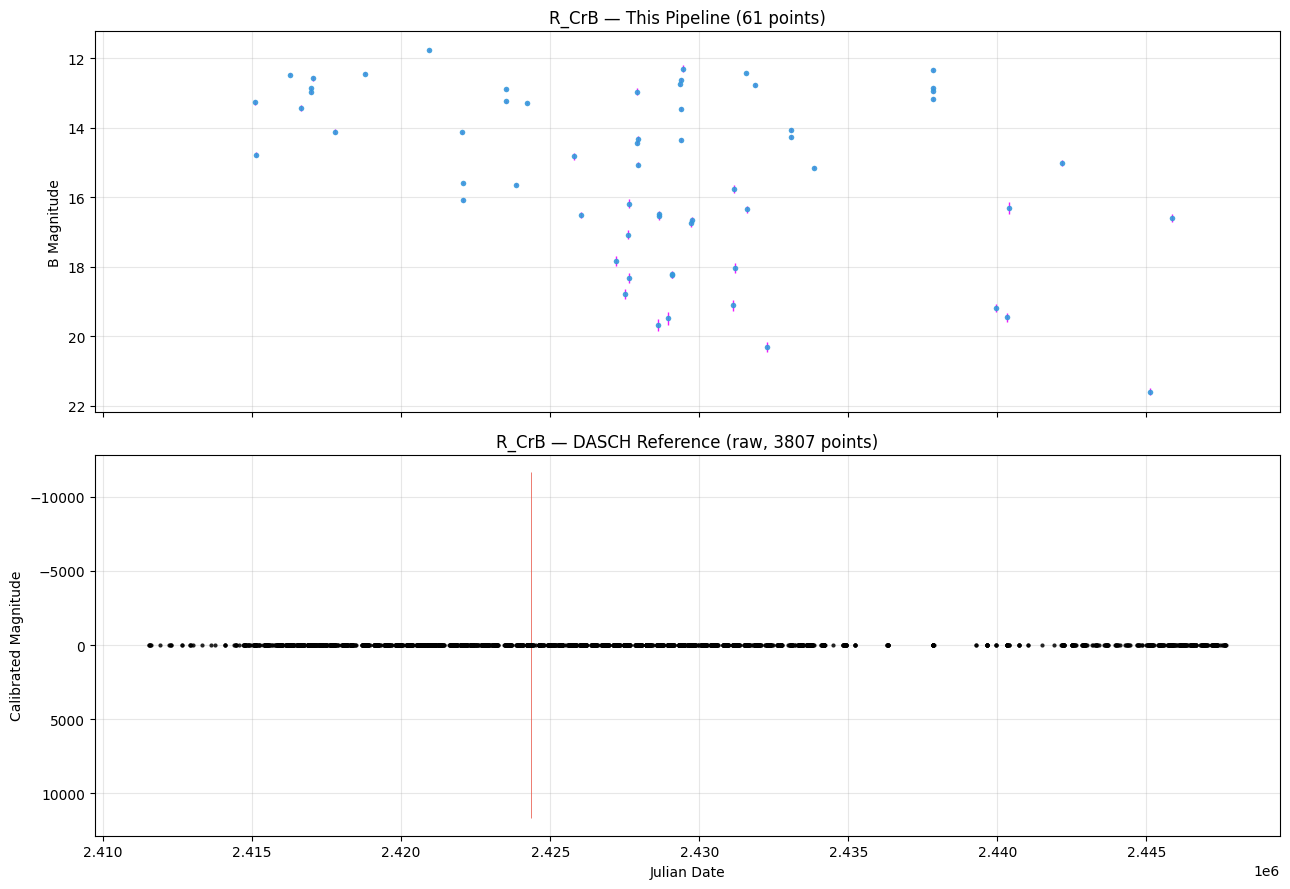

Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\RS_Tel`
- Query target: `RS Tel`
- Refcat: 9323 sources from `apass`
- Exposures: 6686 relevant exposures
- Querying API ...
- Fetched 3314 rows in 8 seconds and saved as `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\RS_Tel\lightcurves\APASS_J181851.2-463253.ecsv`


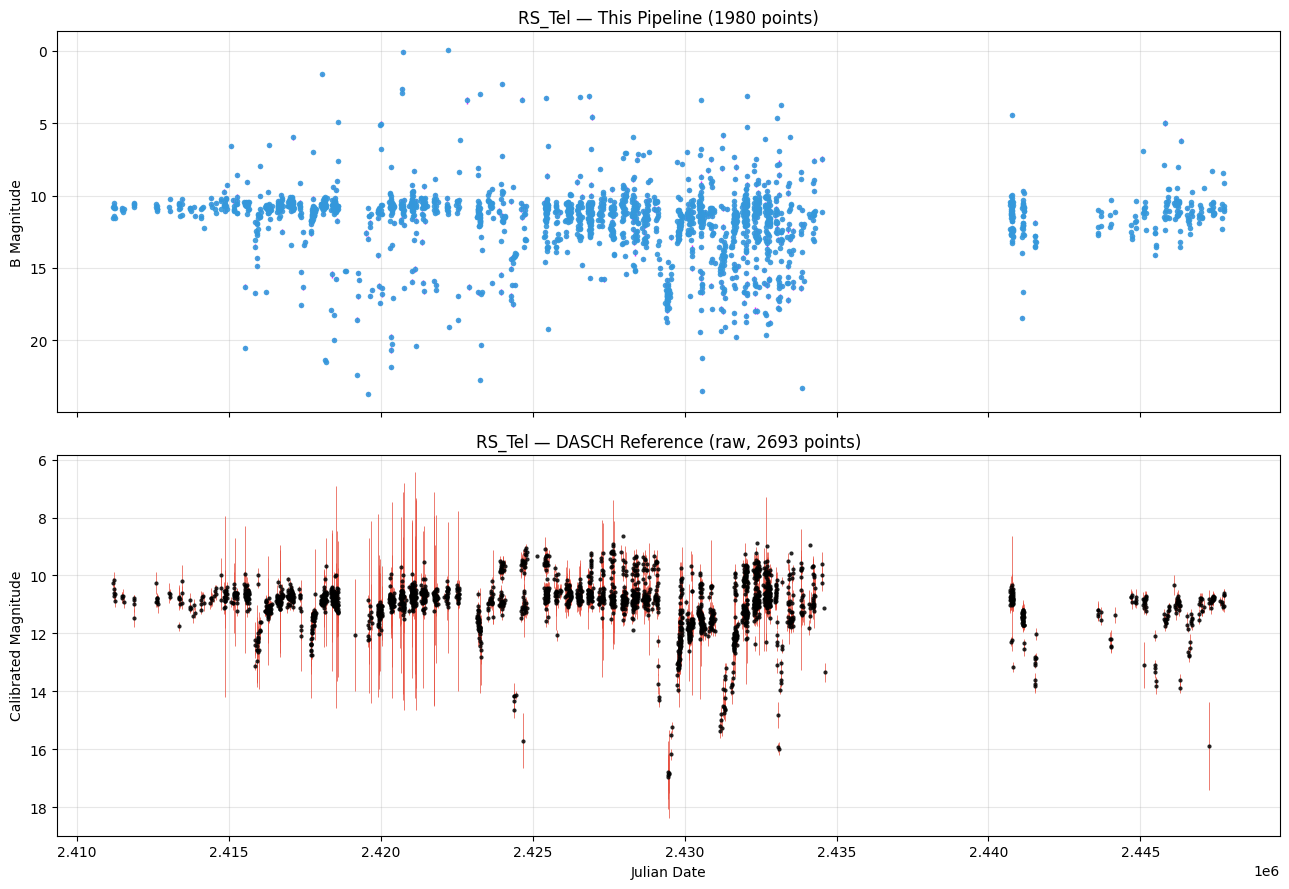

Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\RY_Sgr`
- Query target: `RY Sgr`
- Refcat: 4051 sources from `apass`
- Exposures: 9215 relevant exposures
- Querying API ...
- Fetched 2973 rows in 8 seconds and saved as `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\RY_Sgr\lightcurves\T742726551.ecsv`


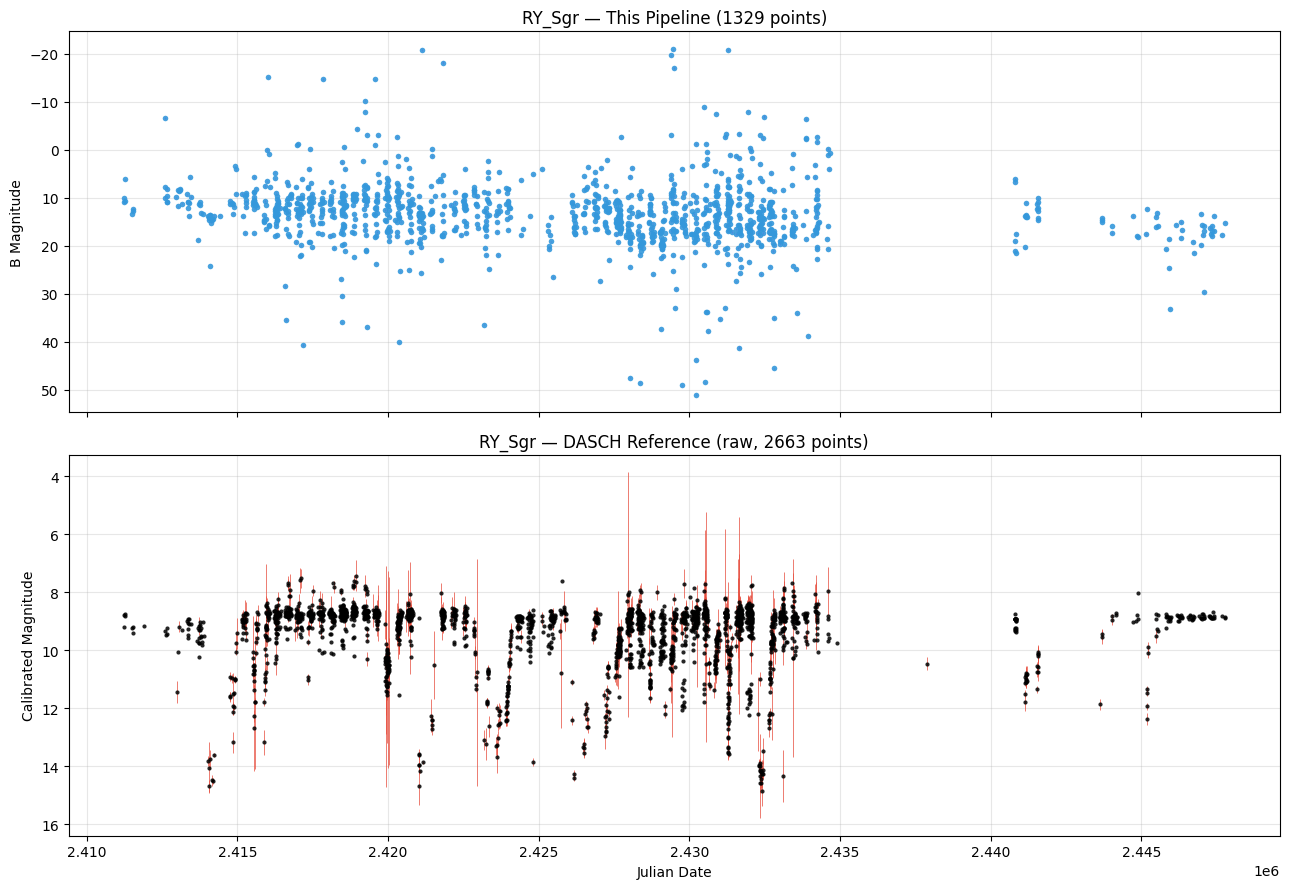

Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\S_Aps`
- Query target: `S Aps`
- Refcat: 8136 sources from `apass`
- Exposures: 8432 relevant exposures
- Querying API ...
- Fetched 4237 rows in 10 seconds and saved as `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\S_Aps\lightcurves\APASS_J150924.5-720345.ecsv`


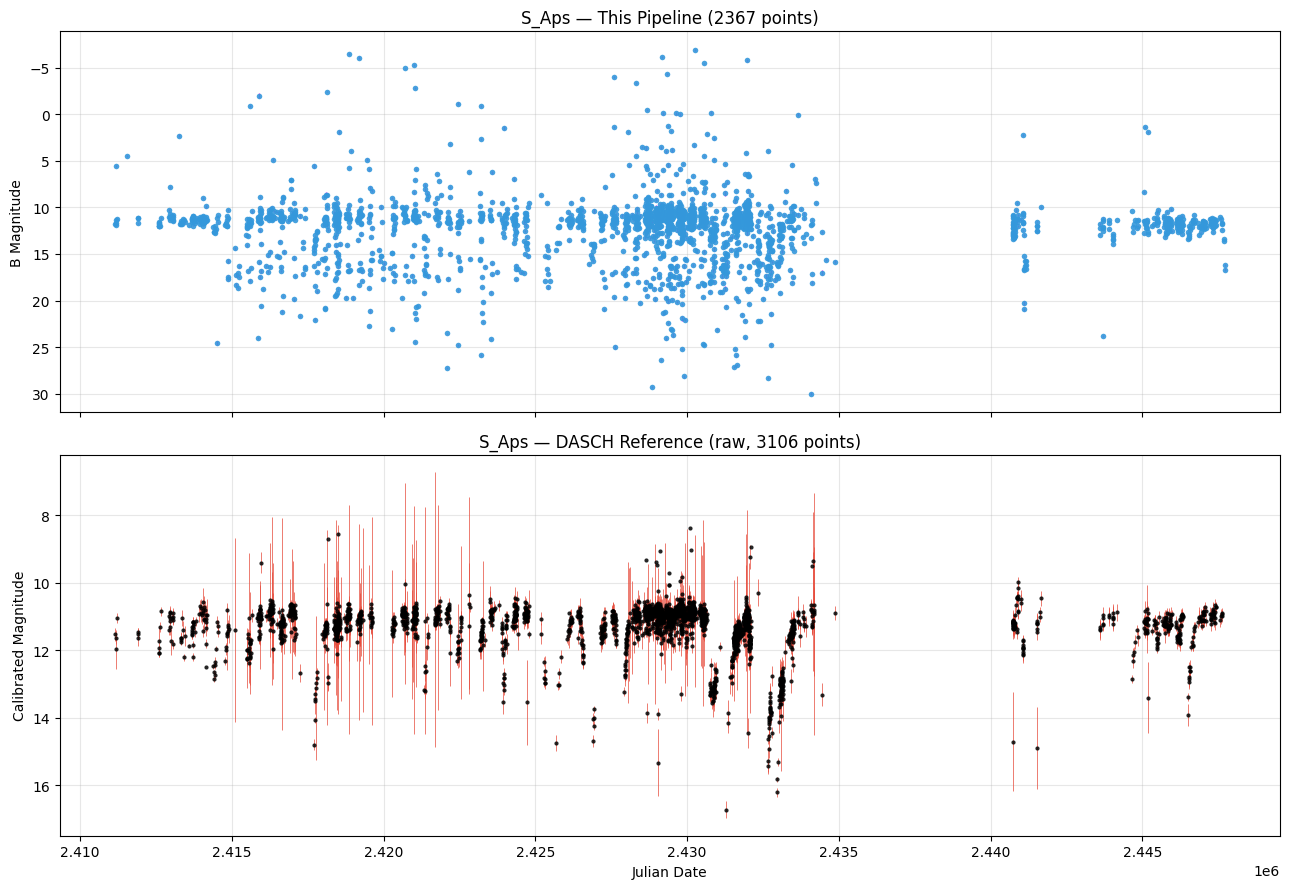

Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\SU_Tau`
- Query target: `SU Tau`
- Refcat: 1923 sources from `apass`
- Exposures: 14377 relevant exposures
- Querying API ...
- Fetched 4096 rows in 10 seconds and saved as `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\SU_Tau\lightcurves\APASS_J054903.7+190422.ecsv`


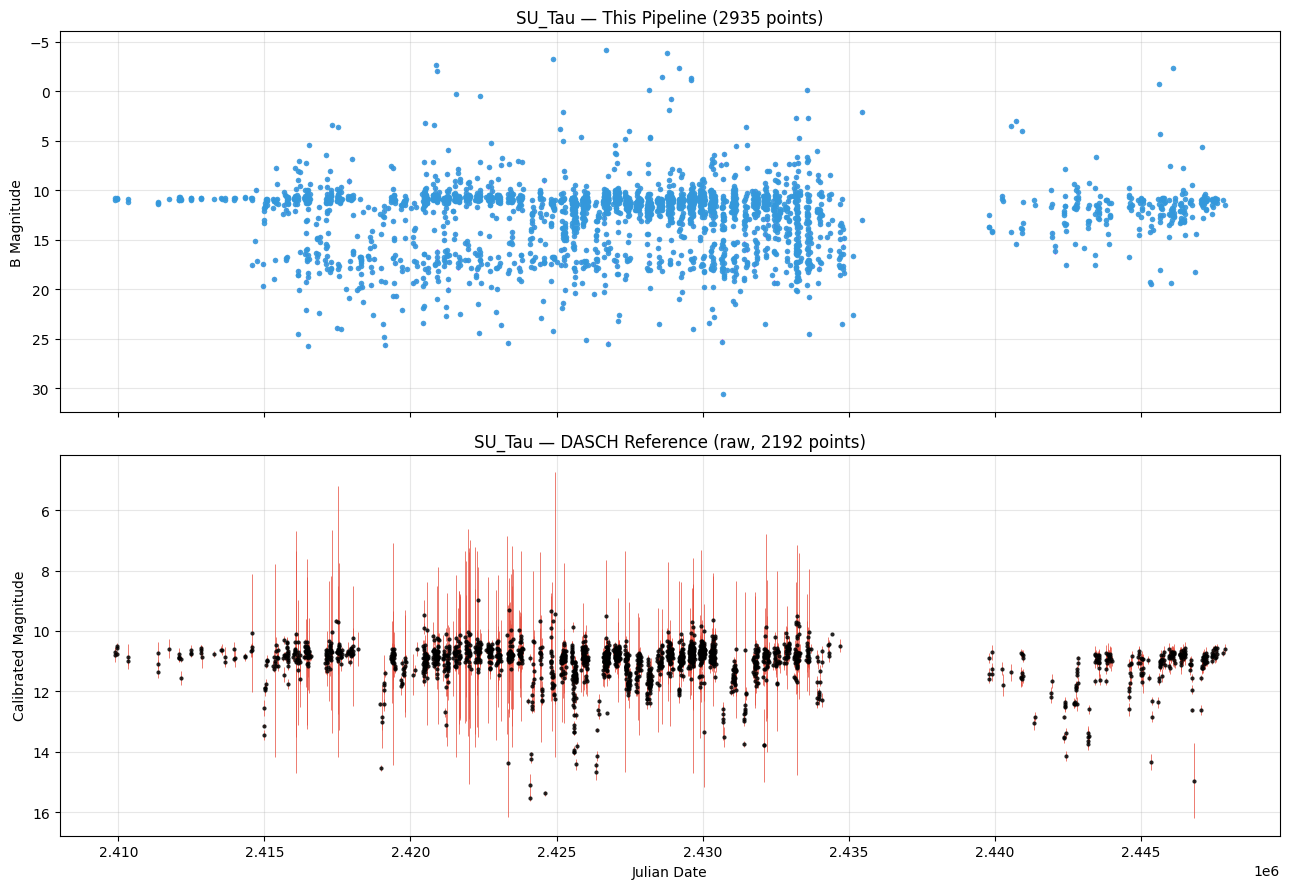

Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\U_Aqr`
- Query target: `U Aqr`
- Refcat: 466 sources from `apass`
- Exposures: 10740 relevant exposures
- Querying API ...
- Fetched 2920 rows in 9 seconds and saved as `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\U_Aqr\lightcurves\S3211333216.ecsv`


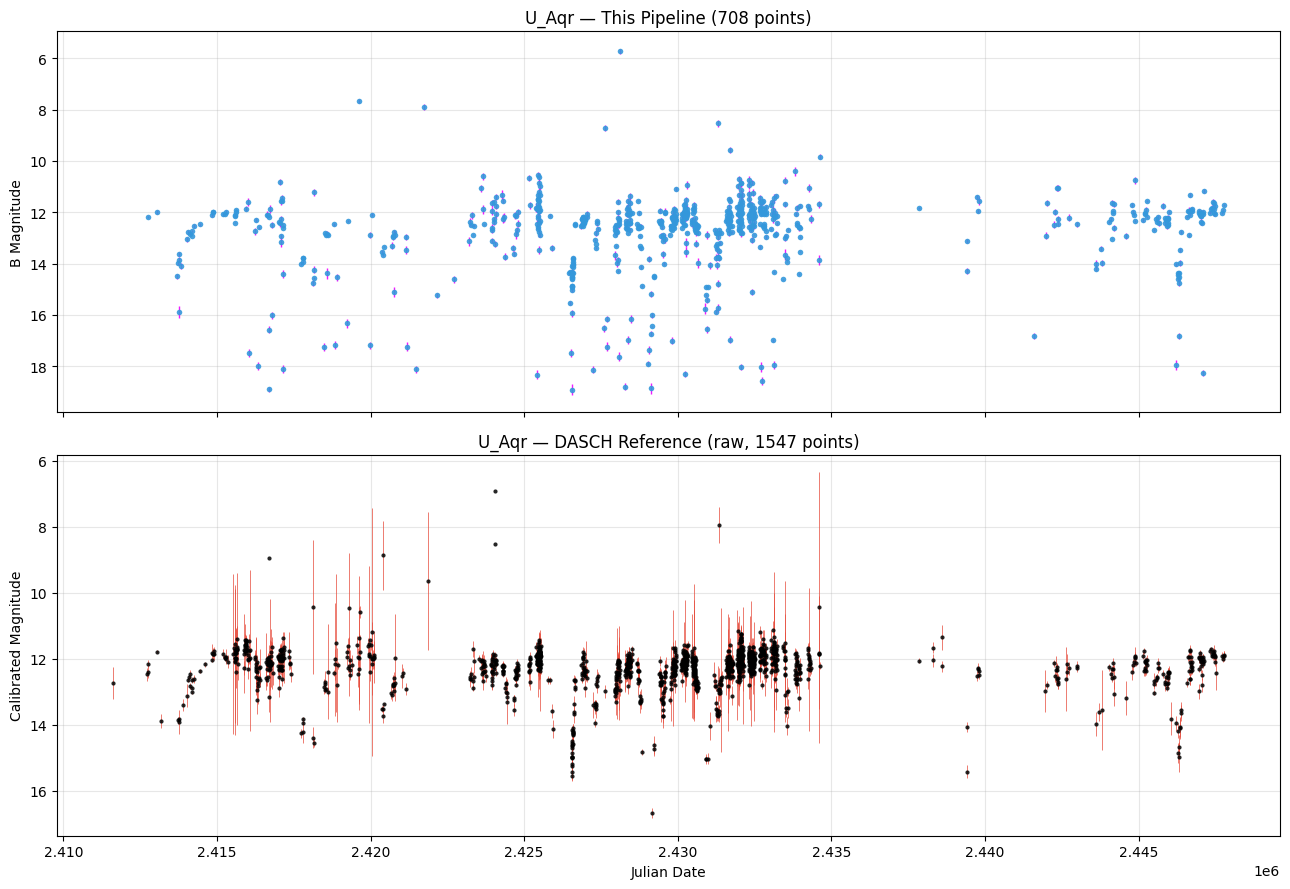

Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\UW_Cen`
- Query target: `UW Cen`
- Refcat: 4380 sources from `apass`
- Exposures: 6039 relevant exposures
- Querying API ...
- Fetched 3277 rows in 10 seconds and saved as `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\UW_Cen\lightcurves\APASS_J124317.2-543141.ecsv`


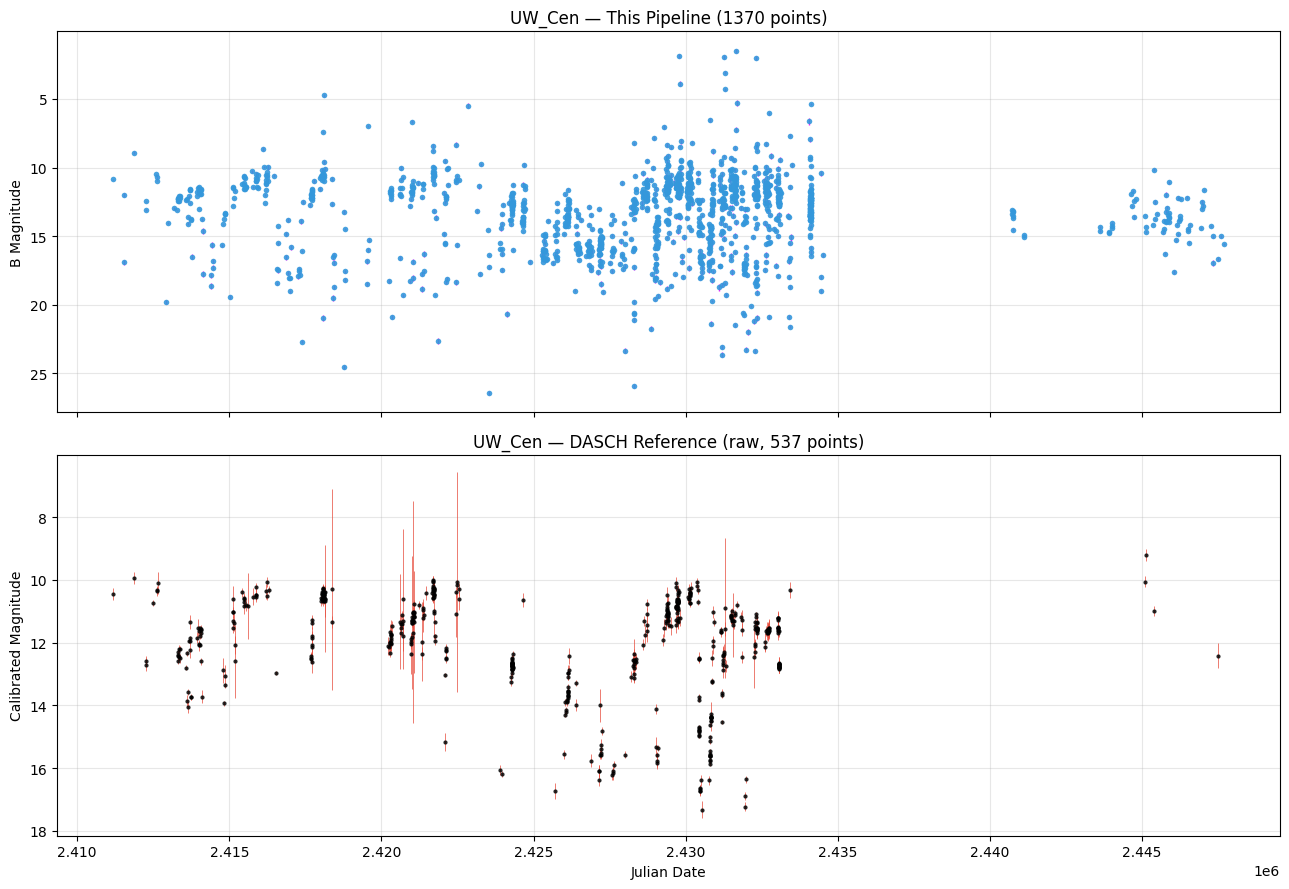

Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\V2552_Oph`
- Query target: `V2552 Oph`
- Refcat: 13153 sources from `apass`
- Exposures: 9186 relevant exposures
- Querying API ...
- Fetched 2638 rows in 10 seconds and saved as `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\V2552_Oph\lightcurves\APASS_J172314.6-225206.ecsv`


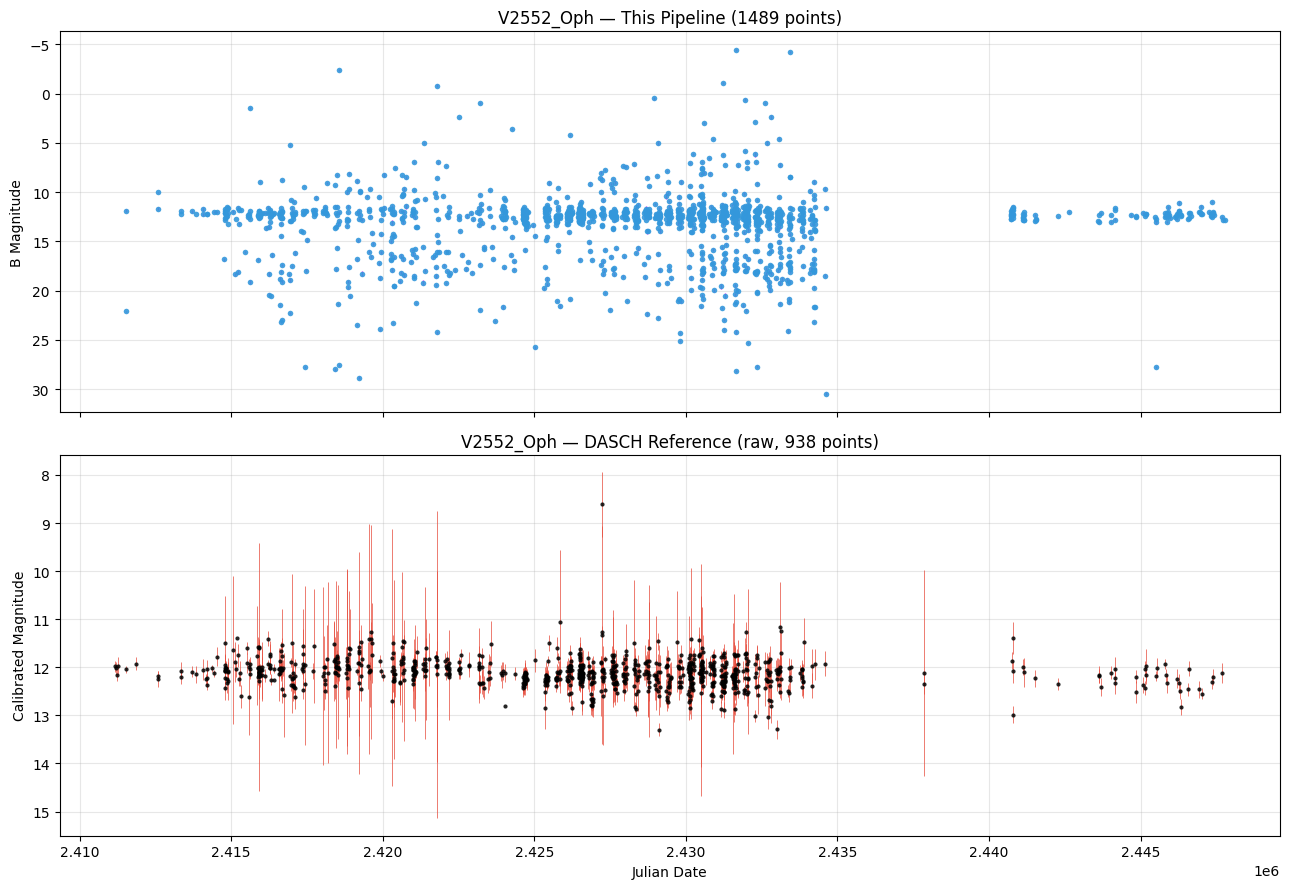

Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\V348_Sgr`
- Query target: `V348 Sgr`
- Refcat: 9059 sources from `apass`
- Exposures: 9885 relevant exposures
- Querying API ...
- Fetched 2455 rows in 8 seconds and saved as `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\V348_Sgr\lightcurves\S303213114650.ecsv`


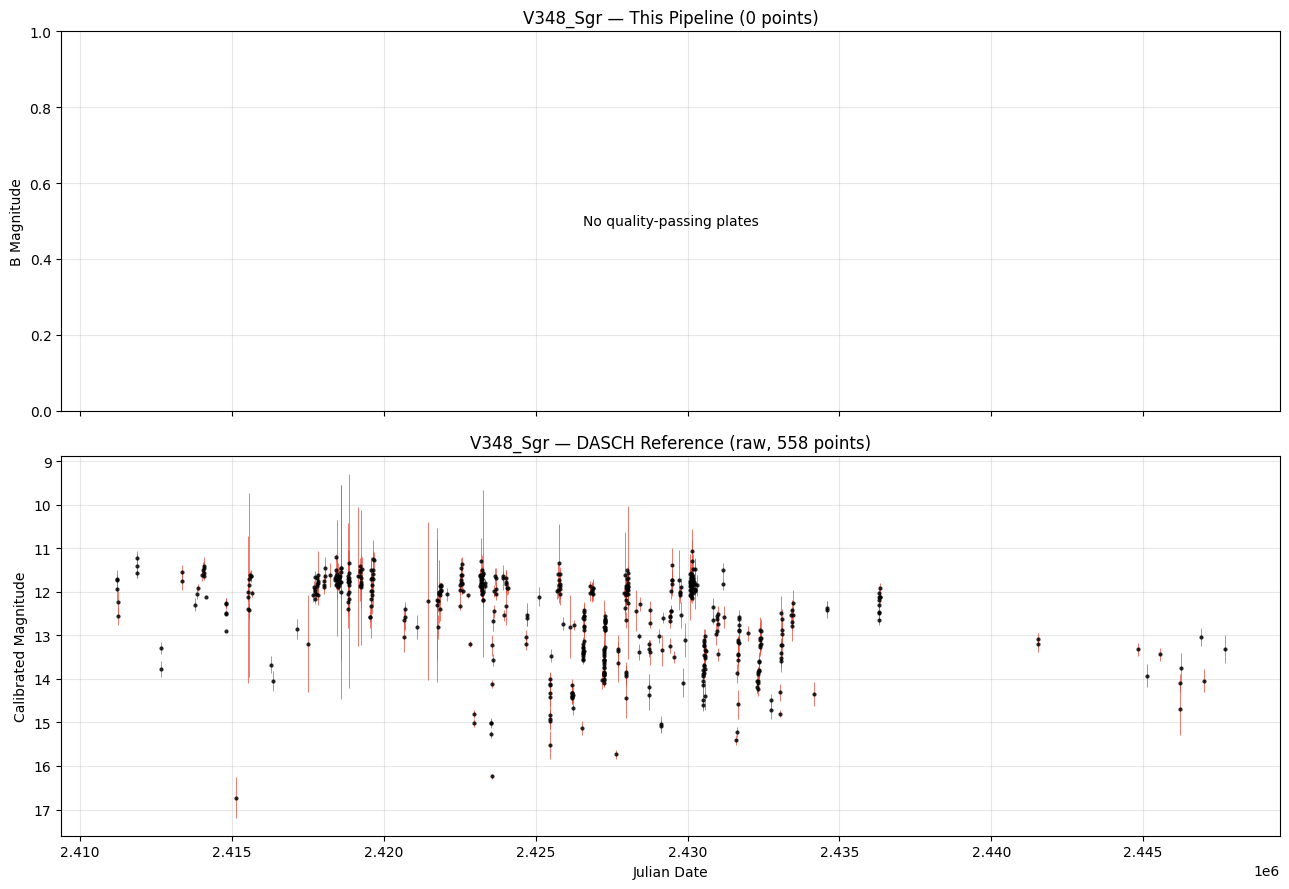

Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\V581_CrA`
- Query target: `V581 CrA`
- Refcat: 8856 sources from `apass`
- Exposures: 6577 relevant exposures
- Querying API ...
- Fetched 3078 rows in 9 seconds and saved as `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\V581_CrA\lightcurves\S332003333516.ecsv`


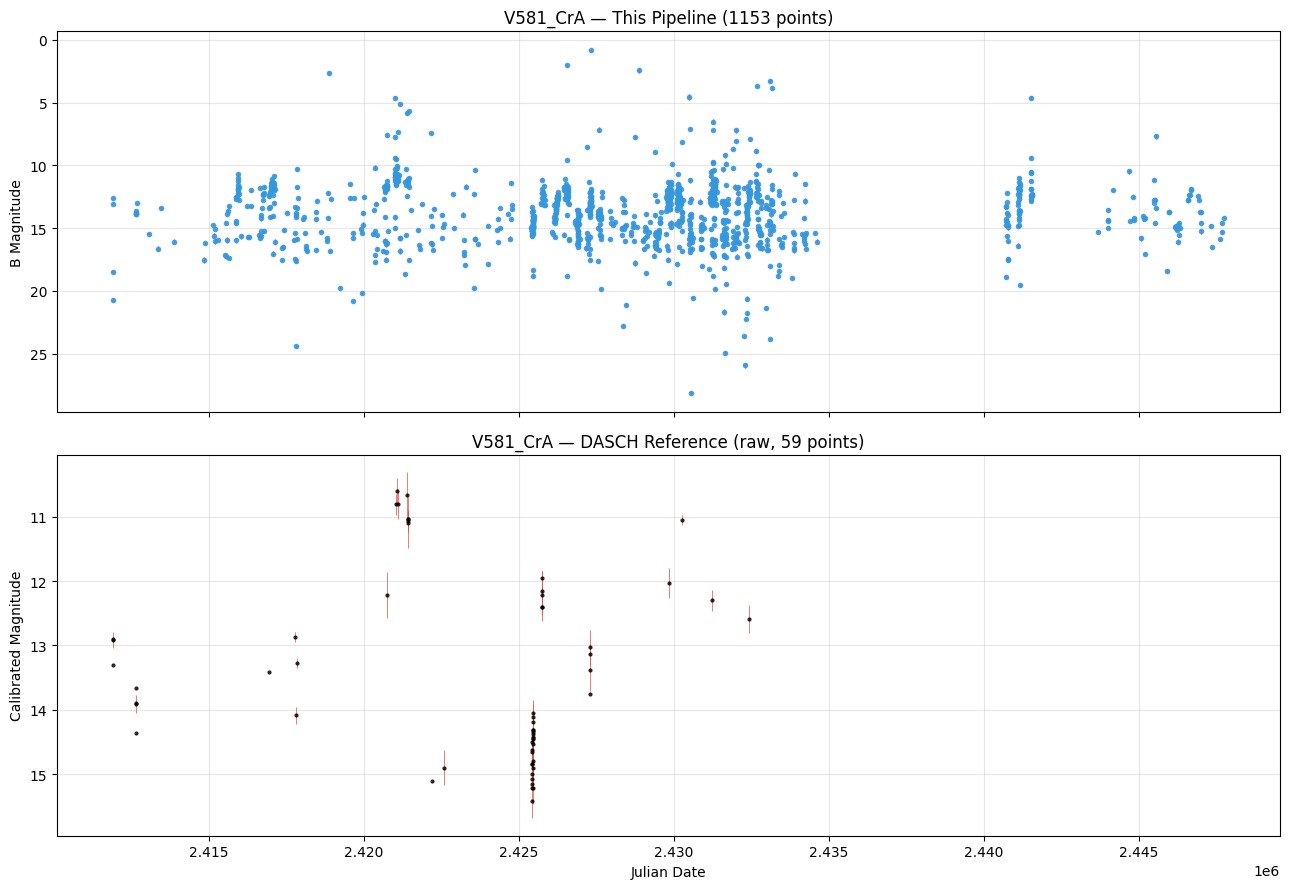

Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\V854_Cen`
- Query target: `V854 Cen`
- Refcat: 1917 sources from `apass`
- Exposures: 6100 relevant exposures
- Querying API ...
- Fetched 2634 rows in 8 seconds and saved as `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\V854_Cen\lightcurves\APASS_J143449.4-393319.ecsv`


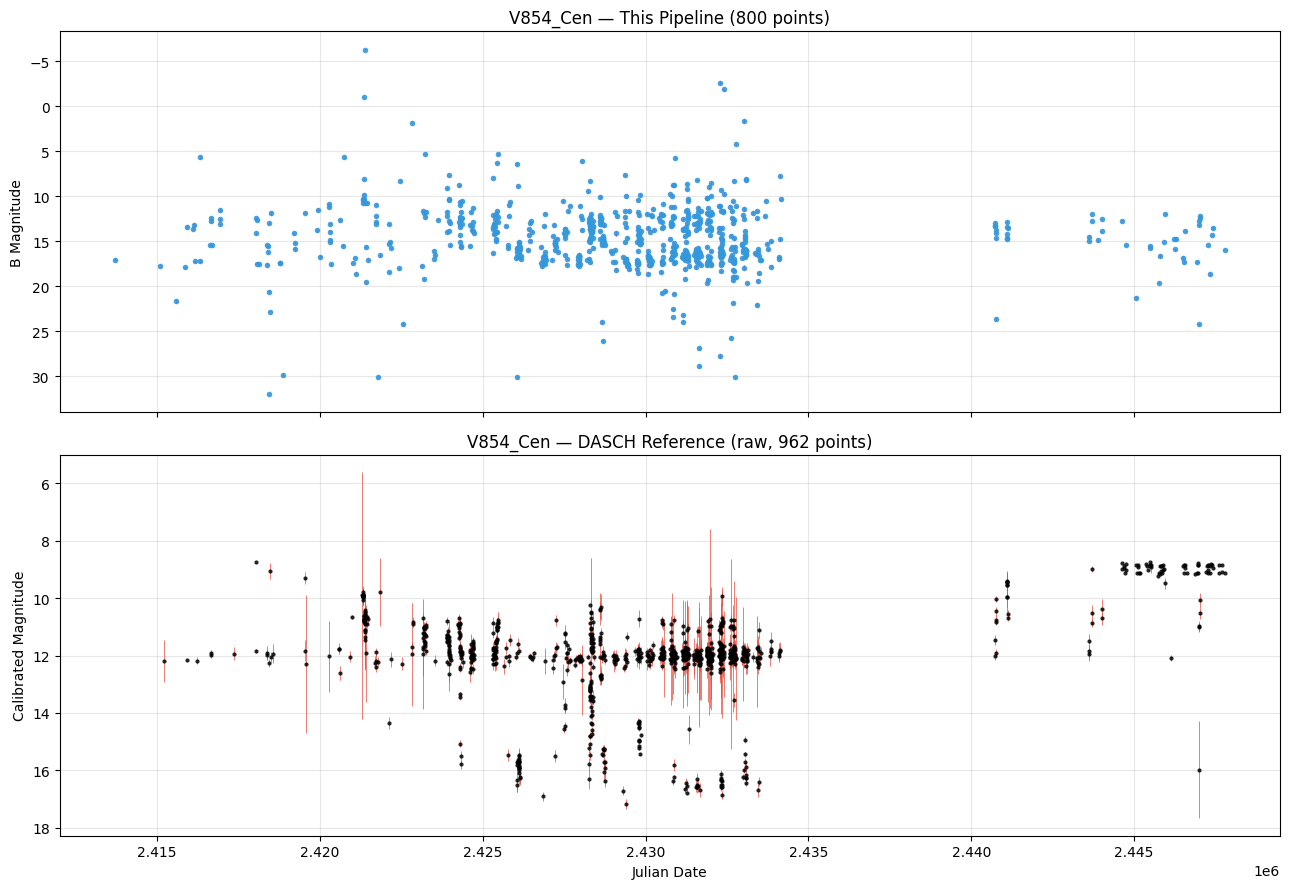

Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\V_CrA`
- Query target: `V CrA`
- Refcat: 4996 sources from `apass`
- Exposures: 7218 relevant exposures
- Querying API ...
- Fetched 2846 rows in 10 seconds and saved as `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\V_CrA\lightcurves\T791514091.ecsv`


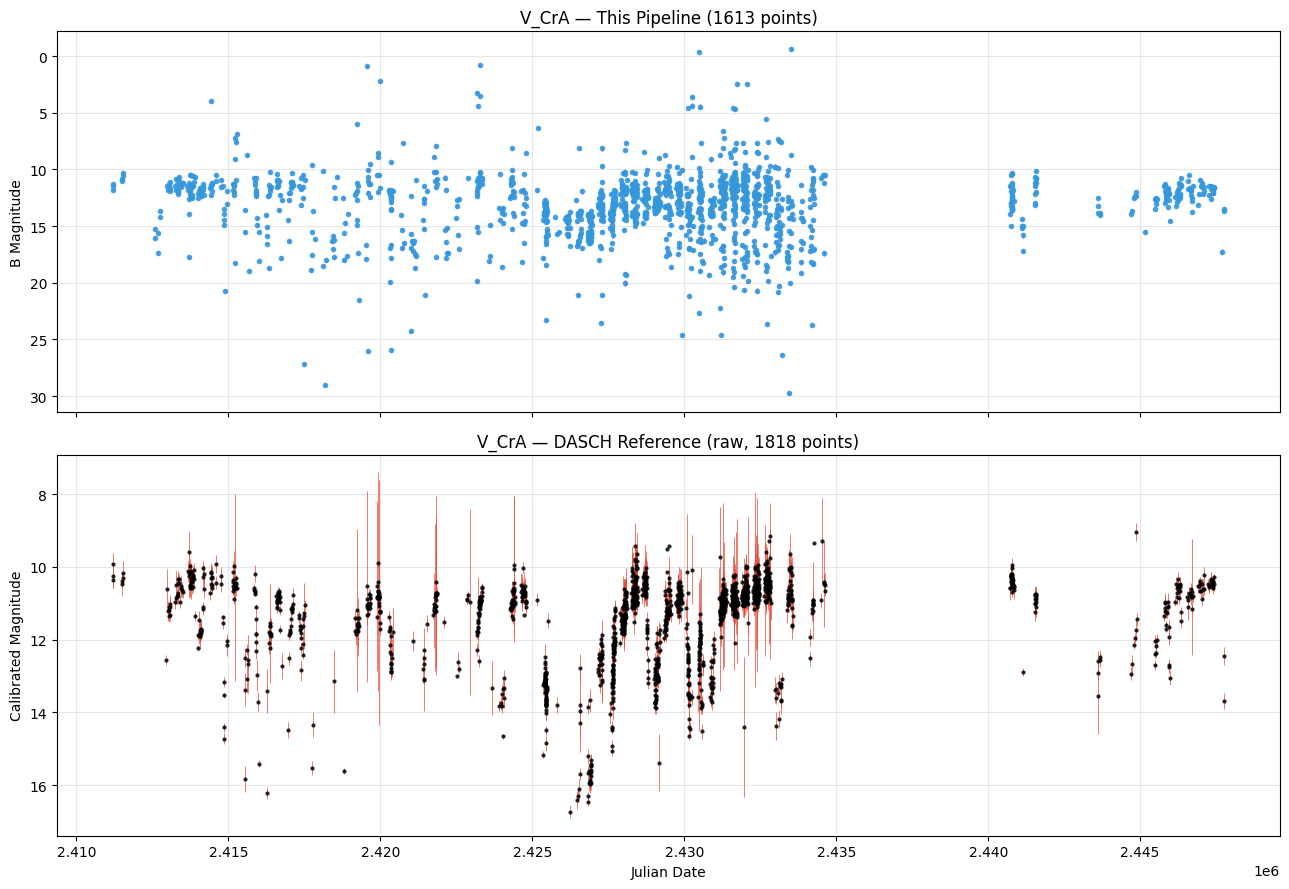

Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\XX_Cam`
- Query target: `XX Cam`
- Refcat: 2572 sources from `apass`
- Exposures: 19115 relevant exposures
- Querying API ...
- Fetched 5336 rows in 16 seconds and saved as `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\XX_Cam\lightcurves\T371816311.ecsv`


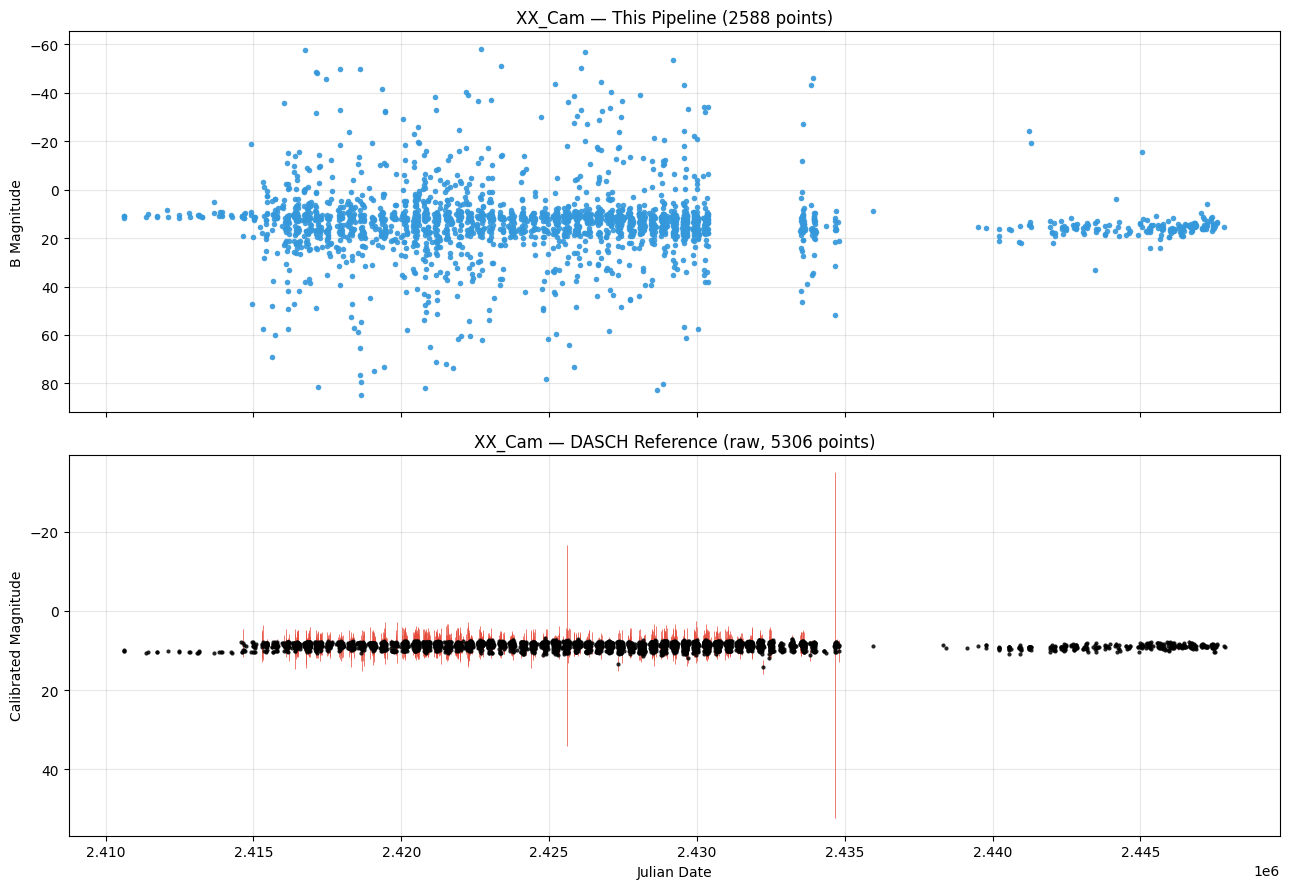

Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\Y_Mus`
- Query target: `Y Mus`
- Refcat: 16776 sources from `apass`
- Exposures: 7007 relevant exposures
- Querying API ...
- Fetched 4040 rows in 9 seconds and saved as `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\Y_Mus\lightcurves\APASS_J130548.2-653047.ecsv`


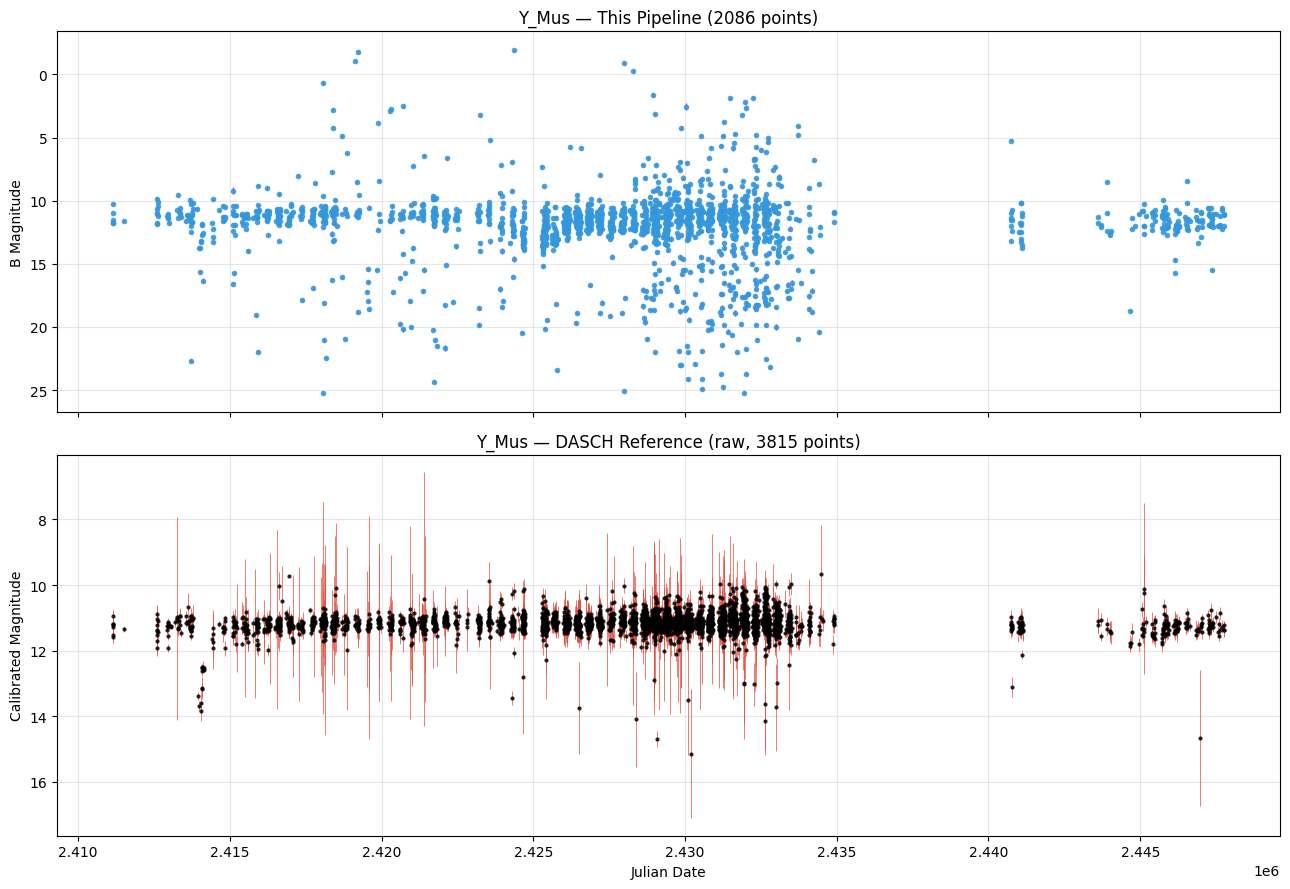


PLOT GENERATION SUMMARY
     star  n_pipeline_points  n_dasch_points
    R_CrB                 61            3807
   RS_Tel               1980            2693
   RY_Sgr               1329            2663
    S_Aps               2367            3106
   SU_Tau               2935            2192
    U_Aqr                708            1547
   UW_Cen               1370             537
V2552_Oph               1489             938
 V348_Sgr                  0             558
 V581_CrA               1153              59
 V854_Cen                800             962
    V_CrA               1613            1818
   XX_Cam               2588            5306
    Y_Mus               2086            3815


In [5]:
# ============================================================================
# 02_A_SiSaP.ipynb - Cell 2: PLOT — reads each star's saved output files and
# generates the This-Pipeline-vs-DASCH comparison plot. Fully self-contained
# (rediscovers star folders from disk) — can be run independently, any time
# after Cell 1 has produced output files, even after a kernel restart.
# ============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DATA_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data")

star_dirs = sorted([d for d in BASE_DATA_DIR.iterdir()
                     if d.is_dir() and (d / 'cutouts').is_dir()])
print(f"Found {len(star_dirs)} star folders. Generating comparison plots...")

plot_summaries = []

for star_dir in star_dirs:
    lc_path = star_dir / '02_A' / 'lightcurve.csv'
    if not lc_path.exists():
        print(f"⚠ {star_dir.name}: no lightcurve.csv found (Cell 1 hasn't been run for this star yet) — skipping.")
        continue

    lc_df = pd.read_csv(lc_path)

    # --- Fetch DASCH comparison for this star ---
    dasch_jd, dasch_mag, dasch_mag_err = None, None, None
    try:
        from daschlab import Session
        query_name = star_dir.name.replace('_', ' ')

        sess = Session(str(star_dir))
        sess.select_target(query_name)
        sess.select_refcat("apass")
        dlc = sess.lightcurve(0)

        dasch_jd_raw = np.asarray(dlc["time"].jd)
        dasch_mag_raw = np.asarray(dlc["magcal_magdep"].value)
        if "magcal_local_rms" in dlc.colnames:
            dasch_err_raw = np.asarray(dlc["magcal_local_rms"].value)
        else:
            dasch_err_raw = np.full_like(dasch_mag_raw, np.nan)

        good = np.isfinite(dasch_jd_raw) & np.isfinite(dasch_mag_raw)
        dasch_jd, dasch_mag = dasch_jd_raw[good], dasch_mag_raw[good]
        dasch_mag_err = dasch_err_raw[good]
    except Exception as e:
        print(f"  ⚠ Could not fetch DASCH light curve for {star_dir.name}: {e}")

    # --- Combined comparison plot ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

    if len(lc_df) > 0:
        ax1.errorbar(lc_df['jd'], lc_df['magnitude'], yerr=lc_df['magnitude_error'],
                     fmt='o', color='#3498db', markersize=4,
                     ecolor='#ef00ff', elinewidth=1.0, capsize=1.5, capthick=0.6,
                     alpha=0.9, markeredgewidth=0)
        ax1.invert_yaxis()
    else:
        ax1.text(0.5, 0.5, 'No quality-passing plates', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_ylabel('B Magnitude')
    ax1.set_title(f'{star_dir.name} — This Pipeline ({len(lc_df)} points)')
    ax1.grid(True, alpha=0.3)

    if dasch_jd is not None and len(dasch_jd) > 0:
        ax2.errorbar(dasch_jd, dasch_mag, yerr=dasch_mag_err,
                     fmt='o', color='black', markersize=3,
                     ecolor='#e74c3c', elinewidth=0.6, capsize=1.2, capthick=0.5,
                     alpha=0.85, markeredgewidth=0)
        ax2.invert_yaxis()
        ax2.set_title(f'{star_dir.name} — DASCH Reference (raw, {len(dasch_jd)} points)')
    else:
        ax2.text(0.5, 0.5, 'DASCH light curve unavailable', ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title(f'{star_dir.name} — DASCH Reference (unavailable)')
    ax2.set_xlabel('Julian Date')
    ax2.set_ylabel('Calibrated Magnitude')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    plot_summaries.append({
        'star': star_dir.name,
        'n_pipeline_points': len(lc_df),
        'n_dasch_points': len(dasch_jd) if dasch_jd is not None else 0,
    })

print("\n" + "=" * 70)
print("PLOT GENERATION SUMMARY")
print("=" * 70)
summary_df = pd.DataFrame(plot_summaries)
if len(summary_df) > 0:
    print(summary_df.to_string(index=False))